## Exploratory Data Analysis

### Importing Libraries and Loading Cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid", palette="Set2")

# Load cleaned data
df = pd.read_csv("../data/processed/superstore_clean.csv", 
                 parse_dates=['Order_Date', 'Ship_Date'])

print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head(3))


Data loaded: 6779 rows × 28 columns


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Quantity,Discount,Profit,Year,Month,Quarter,Day_of_Week,Shipping_Days,Profit_Margin,Revenue_Category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.0,41.9136,2016,11,4,Tuesday,3,16.00,Low
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.0,6.8714,2016,6,2,Sunday,4,47.00,Very Low
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.2,2.5164,2015,10,4,Sunday,7,11.25,Very Low


### Descriptive Statistics

In [2]:
print("------ Descriptive Statistics (Numerical Columns) ------")
display(df[['Sales', 'Profit', 'Discount', 'Quantity', 
            'Shipping_Days', 'Profit_Margin']].describe().round(2))

------ Descriptive Statistics (Numerical Columns) ------


,Sales,Profit,Discount,Quantity,Shipping_Days,Profit_Margin
count,6779.00,6779.00,6779.00,6779.00,6779.00,6779.00
mean,67.00,11.33,0.10,3.45,3.97,26.62
std,84.30,13.05,0.11,2.03,1.75,17.79
min,0.99,-27.72,0.00,1.00,0.00,-68.00
25%,14.94,3.24,0.00,2.00,3.00,11.25
50%,34.79,7.92,0.00,3.00,4.00,31.00
75%,82.60,17.38,0.20,5.00,5.00,39.00
max,496.86,50.58,0.50,14.00,7.00,50.00


### Category Distribution Pie chart

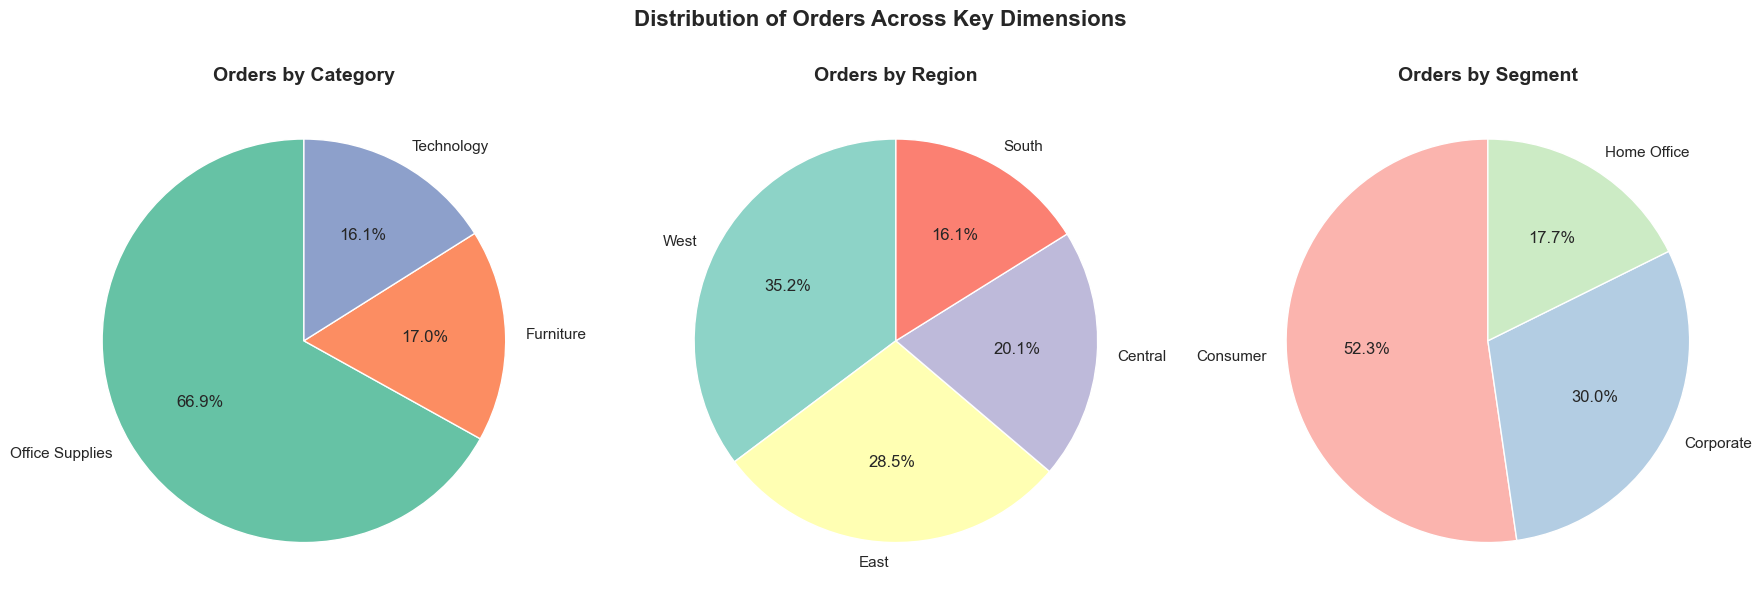

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Category distribution
cat_counts = df['Category'].value_counts()
axes[0].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("Set2"))
axes[0].set_title("Orders by Category", fontsize=14, fontweight='bold')

# Region distribution
reg_counts = df['Region'].value_counts()
axes[1].pie(reg_counts, labels=reg_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("Set3"))
axes[1].set_title("Orders by Region", fontsize=14, fontweight='bold')

# Customer Segment
seg_counts = df['Segment'].value_counts()
axes[2].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("Pastel1"))
axes[2].set_title("Orders by Segment", fontsize=14, fontweight='bold')

plt.suptitle("Distribution of Orders Across Key Dimensions", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Sales & Profit by Region Bar chart

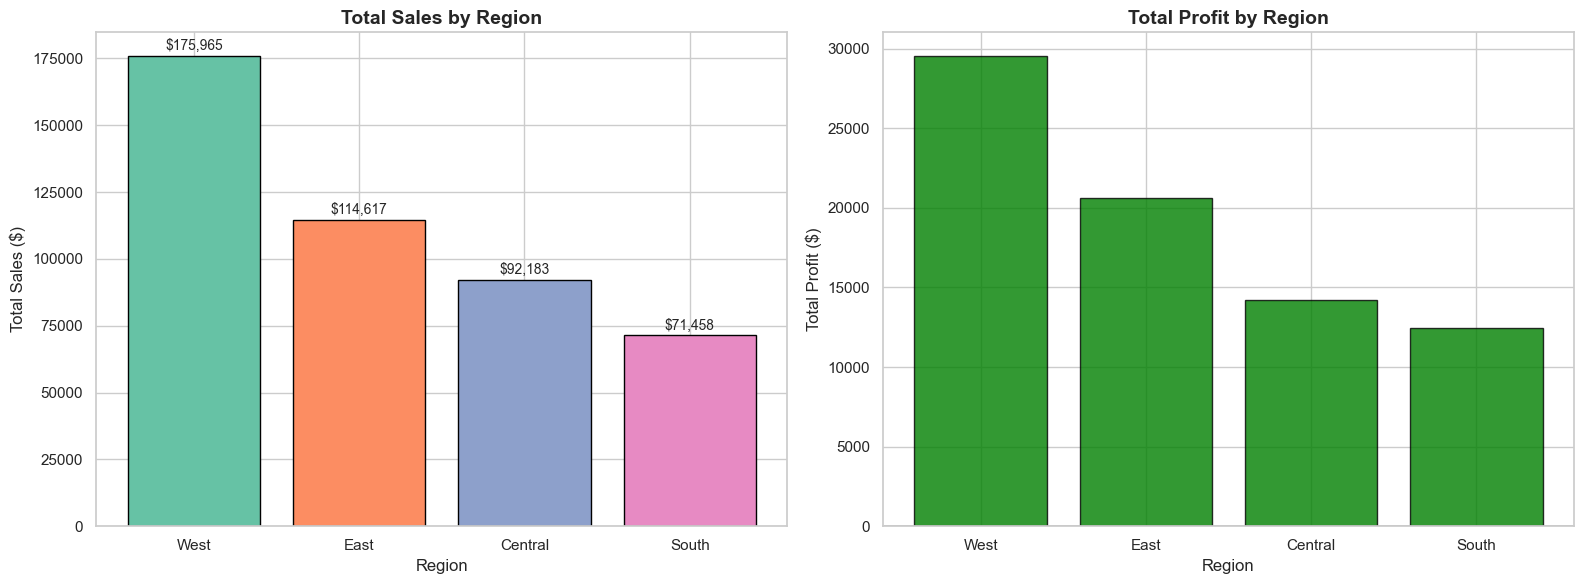

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
bars = axes[0].bar(region_sales.index, region_sales.values, 
                    color=sns.color_palette("Set2"), edgecolor='black')
axes[0].set_title("Total Sales by Region", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Total Sales ($)")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)

# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
colors = ['green' if p > 0 else 'red' for p in region_profit.values]
bars2 = axes[1].bar(region_profit.index, region_profit.values, 
                     color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title("Total Profit by Region", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Total Profit ($)")
axes[1].axhline(y=0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

### Monthly Sales trend

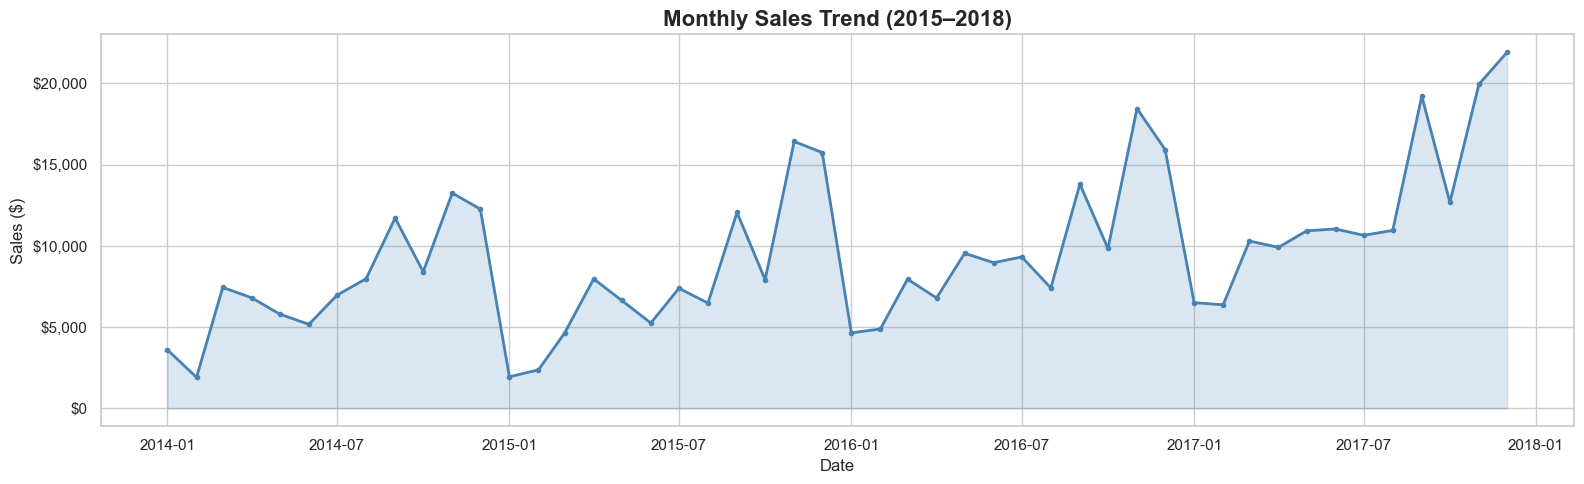

In [5]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(16, 5))
plt.plot(monthly_sales.index, monthly_sales.values, 
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.2, color='steelblue')
plt.title("Monthly Sales Trend (2015–2018)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Correlation Heatmap

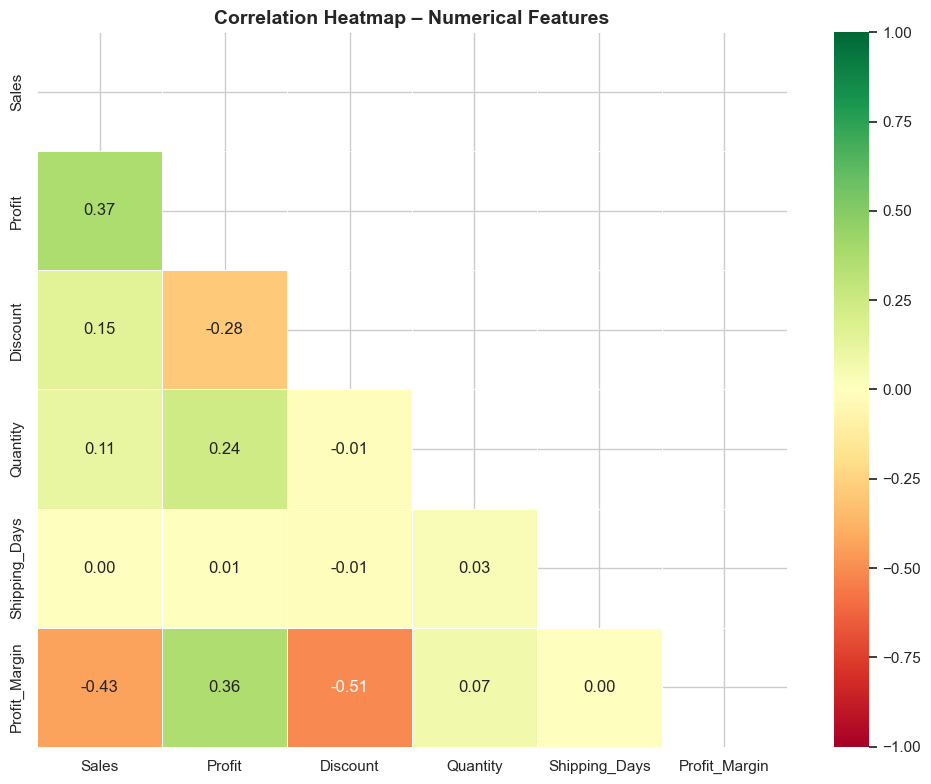


Key Insights from Correlation:
  - Discount vs Profit: Strong NEGATIVE correlation (discounts hurt profits)
  - Sales vs Profit: Moderate POSITIVE correlation
  - Quantity vs Sales: Moderate POSITIVE correlation


In [7]:
plt.figure(figsize=(10, 8))

numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity', 
                'Shipping_Days', 'Profit_Margin']
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 12})

plt.title("Correlation Heatmap – Numerical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insights from Correlation:")
print("  - Discount vs Profit: Strong NEGATIVE correlation (discounts hurt profits)")
print("  - Sales vs Profit: Moderate POSITIVE correlation")
print("  - Quantity vs Sales: Moderate POSITIVE correlation")

### Profit by Sub category

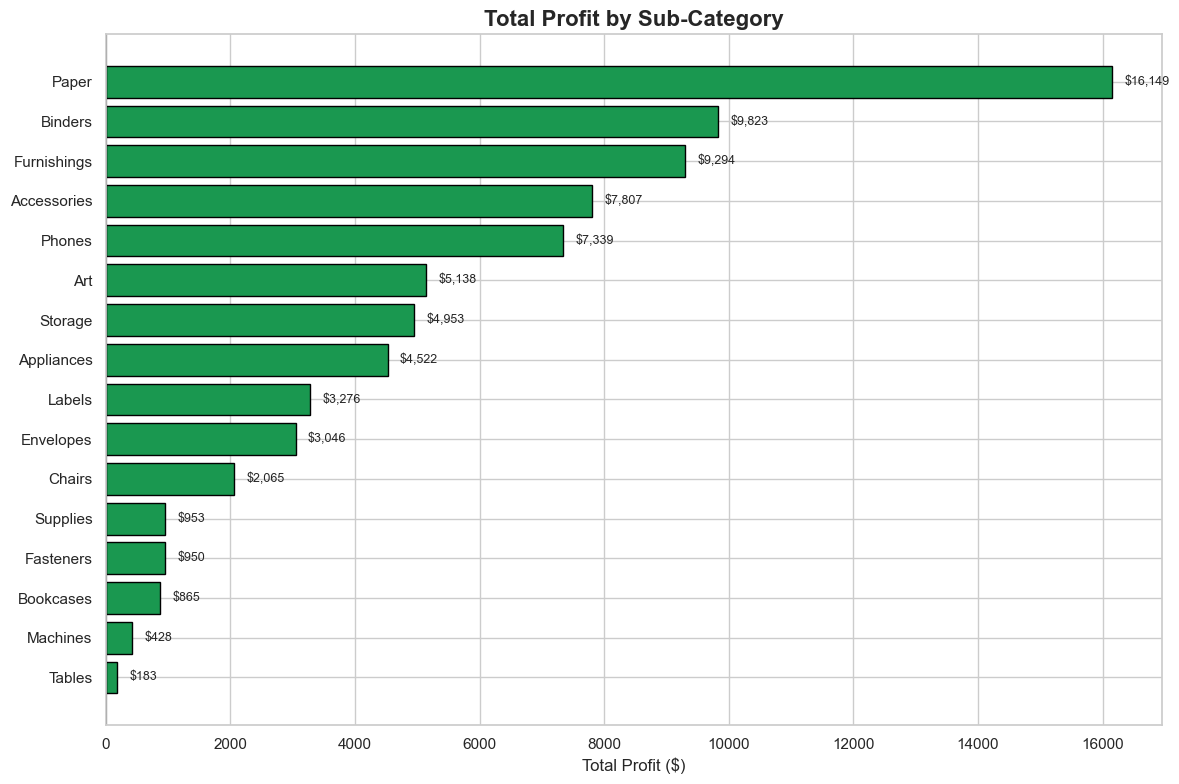

In [10]:
subcat_profit = df.groupby('Sub_Category')['Profit'].sum().sort_values()

colors = ['#d73027' if p < 0 else '#1a9850' for p in subcat_profit.values]

plt.figure(figsize=(12, 8))
bars = plt.barh(subcat_profit.index, subcat_profit.values, color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.5)
plt.title("Total Profit by Sub-Category", fontsize=16, fontweight='bold')
plt.xlabel("Total Profit ($)")
for bar, val in zip(bars, subcat_profit.values):
    plt.text(val + (200 if val >= 0 else -200), bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

### Sales Distribution

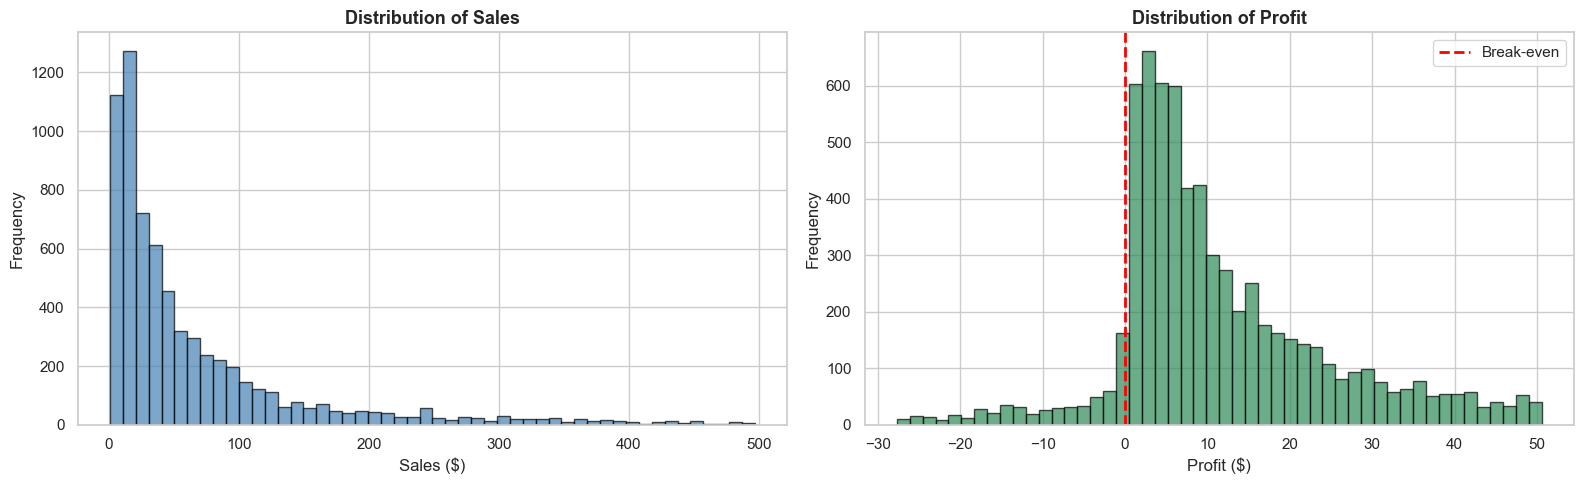

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sales distribution
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of Sales", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Sales ($)")
axes[0].set_ylabel("Frequency")

# Profit distribution
colors_profit = ['red' if x < 0 else 'green' for x in df['Profit']]
axes[1].hist(df['Profit'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
axes[1].set_title("Distribution of Profit", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Profit ($)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

### Top States by sales

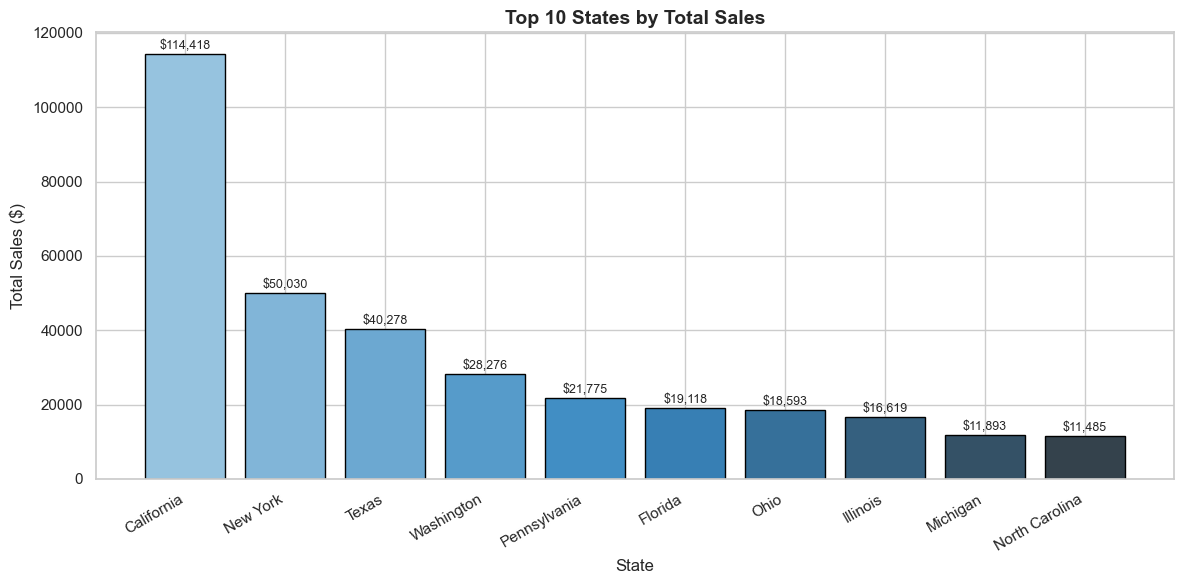

In [12]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(state_sales.index, state_sales.values, 
               color=sns.color_palette("Blues_d", 10), edgecolor='black')
plt.title("Top 10 States by Total Sales", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=30, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Summary

In [14]:
print("         EDA SUMMARY – KEY INSIGHTS")
print("-" * 60)
print(f"\nDataset Overview:")
print(f"   Orders       : {df.shape[0]:,}")
print(f"   Time Period  : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
print(f"   Total Sales  : ${df['Sales'].sum():,.2f}")
print(f"   Total Profit : ${df['Profit'].sum():,.2f}")
print(f"   Avg Margin   : {df['Profit_Margin'].mean():.2f}%")

print(f"\nBest Performing:")
print(f"   Region   : {df.groupby('Region')['Profit'].sum().idxmax()}")
print(f"   Segment  : {df.groupby('Segment')['Profit'].sum().idxmax()}")
print(f"   Category : {df.groupby('Category')['Profit'].sum().idxmax()}")

print(f"\nProblem Areas:")
losing = df.groupby('Sub_Category')['Profit'].sum()
for sc, p in losing[losing < 0].items():
    print(f"   ❌ {sc}: ${p:,.0f} loss")

print(f"\nCorrelation Key Takeaway:")
corr_val = df[['Discount', 'Profit']].corr().loc['Discount', 'Profit']
print(f"   Discount ↔ Profit correlation: {corr_val:.3f} (higher discounts = lower profit)")

         EDA SUMMARY – KEY INSIGHTS
------------------------------------------------------------

Dataset Overview:
   Orders       : 6,779
   Time Period  : 2014-01-03 → 2017-12-30
   Total Sales  : $454,223.18
   Total Profit : $76,789.99
   Avg Margin   : 26.62%

Best Performing:
   Region   : West
   Segment  : Consumer
   Category : Office Supplies

Problem Areas:

Correlation Key Takeaway:
   Discount ↔ Profit correlation: -0.282 (higher discounts = lower profit)
